# Innit


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import random


from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.decomposition import PCA

from sklearn.linear_model import Ridge

from sklearn.feature_selection import RFE

from lightgbm import LGBMRegressor


from pycaret.regression import *


def set_seeds(seed=42):
    """
    Sets the seed for reproducibility across Python, NumPy, and TensorFlow.
    """
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    # tf.random.set_seed(seed)
    # For newer versions of TF/Keras to ensure deterministic behavior on GPU if possible
    os.environ['TF_DETERMINISTIC_OPS'] = '1'
    print(f"Random seed set to: {seed}")
set_seeds(42)


Random seed set to: 42


## Functions


In [2]:
def working_df(data, gw, features=None):

    GW_full = data['round'].values

    # Split
    GW_TRAIN_END = gw - 1
    train_mask = GW_full <= GW_TRAIN_END
    test_mask = GW_full == (GW_TRAIN_END + 1)

    train_data = data[train_mask]
    test_data = data[test_mask]

    test_player_names = test_data['fpl_name'].values
    test_player_ids = test_data['fpl_id'].values
    # test_player_positions = test_data['position'].values
    test_data = test_data.drop(columns=['fpl_name', 'fpl_id', 'team_id', 'round'])
    train_data = train_data.drop(columns=['fpl_name', 'fpl_id', 'team_id', 'round'])

    return train_data, test_data, test_player_names, test_player_ids, test_mask

def plot_preds(preds, position, gw, full_data, test_mask):
    # xp_actual = test_target
    # xp_pred = preds #['prediction_label'].values
    # position = data_25_26[test_mask]['position'].values

    preds_data = pd.DataFrame({
        'fpl_name': full_data[test_mask]['fpl_name'].values,
        'Actual_xP':  full_data[test_mask]['xP'].values,
        'Pred_xP': preds,
        'position': full_data[test_mask]['position'].values
    })

    position = position
    names = preds_data[preds_data['position'] == position]['fpl_name'].values
    xp_actual = preds_data[preds_data['position'] == position]['Actual_xP'].values
    xp_pred = preds_data[preds_data['position'] == position]['Pred_xP'].values


    # Convert names to positions on x-axis
    x = np.arange(len(names))

    plt.figure(figsize=(14, 6))

    # Plot actual points
    plt.plot(x, xp_actual, marker='o', linewidth=2, label='Actual Points')

    # Plot predicted points
    plt.plot(x, xp_pred, marker='x', linewidth=2, label='Predicted Points')

    # Improve readability
    plt.xticks(x, names, rotation=75, ha='right')
    plt.xlabel("Players")
    plt.ylabel("Points")
    plt.title(f" : Actual vs Predicted Points per Player for position {position} (GW {gw})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Width of each bar
    width = 0.31

    plt.figure(figsize=(14, 6))

    # Bars
    plt.bar(x - width/2, xp_actual, width, label='Actual Points')
    plt.bar(x + width/2, xp_pred, width, label='Predicted Points')

    # Labels & formatting
    plt.xticks(x, names, rotation=75, ha='right')
    plt.xlabel("Players")
    plt.ylabel("Points")
    plt.title(f" {position} : Actual vs Predicted Points per Player for position {position} (GW {gw})")
    plt.legend()

    plt.tight_layout()
    plt.show()


# Data Prep


In [3]:
# data_25_26 = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/Prediction%20with%20Affine%20PNN/data/rolled_player_data.csv')
data_25_26 = pd.read_csv('../Prediction with Affine PNN/data/rolled_player_data.csv')
data_25_26

,fpl_id,round,first_name,second_name,web_name,now_cost,selected_by_percent,form,event_points,transfers_in_event,...,strength_attack_away_5_ewm,strength_defence_home_1_ewm,strength_defence_home_3_ewm,strength_defence_home_5_ewm,strength_defence_away_1_ewm,strength_defence_away_3_ewm,strength_defence_away_5_ewm,opp_clean_sheets,opp_elo,opp_strength
0,1.0,1,David,Raya Martín,Raya,6.0,36.9,3.2,10.0,418466.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.000000
1,1.0,2,David,Raya Martín,Raya,5.5,21.5,8.0,6.0,77335.0,...,1350.0,1290.0,1290.0,1290.0,1300.0,1300.0,1300.0,1.000000,2037.000000,4.000000
2,1.0,3,David,Raya Martín,Raya,5.5,21.8,6.0,2.0,38830.0,...,1350.0,1290.0,1290.0,1290.0,1300.0,1300.0,1300.0,1.000000,1993.000000,5.000000
3,1.0,4,David,Raya Martín,Raya,5.5,23.5,6.0,6.0,33143.0,...,1350.0,1290.0,1290.0,1290.0,1300.0,1300.0,1300.0,1.000000,2037.000000,4.000000
4,1.0,5,David,Raya Martín,Raya,5.5,24.0,4.0,2.0,95889.0,...,1350.0,1290.0,1290.0,1290.0,1300.0,1300.0,1300.0,0.000000,2037.000000,4.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7328,804.0,24,João Victor,de Souza Menezes,Souza,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.078268,1788.454552,3.091083
7329,805.0,24,Lorenzo,Lucca,Lucca,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.438398,1845.507974,3.097940
7330,806.0,24,Christos,Mandas,Mandas,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.394673,1826.743534,3.036766
7331,807.0,24,Rayan Vitor,Simplício Rocha,Rayan,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.394673,1826.743534,3.036766


In [4]:

gw=24

cols = [

    'fpl_id', 'round', 'fpl_name', 'position', 'team_id', 'team', 'opponent_team', 'was_home', 'xP',# 'xP_next',
    'selected_by_percent','value', 'transfers_in', 'transfers_out',  'selected', 'ownership_change', 'percenatge_net_transfers',
    'cbitr_volume_90', 'cbitr_ewm_90', 'cbitr_ewm_probability',  'cbitr_probability','elo',  'team_h_difficulty', 'team_a_difficulty',
    'win_prob', 'draw_prob', 'lose_prob',


    'creativity_rolling_1', 'creativity_rolling_3', 'creativity_rolling_5', 'influence_rolling_1', 'influence_rolling_3', 'influence_rolling_5', 'threat_rolling_1',
    'threat_rolling_3', 'threat_rolling_5', 'minutes_rolling_1', 'minutes_rolling_3', 'minutes_rolling_5', 'pts_bonus_rolling_1', 'pts_bonus_rolling_3',
    'pts_bonus_rolling_5', 'expected_goals_rolling_1', 'expected_goals_rolling_3', 'expected_goals_rolling_5', 'expected_assists_rolling_1',
    'expected_assists_rolling_3', 'expected_assists_rolling_5', 'xP_rolling_1', 'xP_rolling_3', 'xP_rolling_5', 'expected_goals_conceded_rolling_1',
    'expected_goals_conceded_rolling_3', 'expected_goals_conceded_rolling_5', 'goals_conceded_rolling_1', 'goals_conceded_rolling_3', 'goals_conceded_rolling_5',
    'goals_scored_rolling_1', 'goals_scored_rolling_3', 'goals_scored_rolling_5', 'shots_rolling_1', 'shots_rolling_3', 'shots_rolling_5', 'key_passes_rolling_1',
    'key_passes_rolling_3', 'key_passes_rolling_5', 'npg_rolling_1', 'npg_rolling_3', 'npg_rolling_5', 'npxG_rolling_1', 'npxG_rolling_3', 'npxG_rolling_5',
    'goals_rolling_1', 'goals_rolling_3', 'goals_rolling_5', 'xG_rolling_1', 'xG_rolling_3', 'xG_rolling_5', 'xA_rolling_1', 'xA_rolling_3', 'xA_rolling_5',
    'saves_rolling_1', 'saves_rolling_3', 'saves_rolling_5', 'starts_rolling_1', 'starts_rolling_3', 'starts_rolling_5', 'yellow_cards_rolling_1',
    'yellow_cards_rolling_3', 'yellow_cards_rolling_5', 'red_cards_rolling_1', 'red_cards_rolling_3', 'red_cards_rolling_5', 'assists_rolling_1', 'assists_rolling_3',
    'assists_rolling_5', 'clean_sheets_rolling_1', 'clean_sheets_rolling_3', 'clean_sheets_rolling_5', 'value_rolling_1', 'value_rolling_3', 'value_rolling_5',
    'ict_index_rolling_1', 'ict_index_rolling_3', 'ict_index_rolling_5', 'selected_rolling_1', 'selected_rolling_3', 'selected_rolling_5', 'transfers_in_rolling_1',
    'transfers_in_rolling_3', 'transfers_in_rolling_5', 'transfers_out_rolling_1', 'transfers_out_rolling_3', 'transfers_out_rolling_5', 'ownership_change_rolling_1',
    'ownership_change_rolling_3', 'ownership_change_rolling_5', 'percenatge_net_transfers_rolling_1', 'percenatge_net_transfers_rolling_3',
    'percenatge_net_transfers_rolling_5', 'xGChain_rolling_1', 'xGChain_rolling_3', 'xGChain_rolling_5', 'xGBuildup_rolling_1', 'xGBuildup_rolling_3',
    'xGBuildup_rolling_5', 'expected_goal_involvements_rolling_1', 'expected_goal_involvements_rolling_3', 'expected_goal_involvements_rolling_5', 'form_rolling_1',
    'form_rolling_3', 'form_rolling_5', 'clearances_blocks_interceptions_rolling_1', 'clearances_blocks_interceptions_rolling_3',
    'clearances_blocks_interceptions_rolling_5', 'tackles_rolling_1', 'tackles_rolling_3', 'tackles_rolling_5', 'recoveries_rolling_1', 'recoveries_rolling_3',
    'recoveries_rolling_5', 'selected_by_percent_rolling_1', 'selected_by_percent_rolling_3', 'selected_by_percent_rolling_5', 'strength_rolling_1',
    'strength_rolling_3', 'strength_rolling_5', 'strength_overall_home_rolling_1', 'strength_overall_home_rolling_3', 'strength_overall_home_rolling_5',
    'strength_overall_away_rolling_1', 'strength_overall_away_rolling_3', 'strength_overall_away_rolling_5', 'strength_attack_home_rolling_1',
    'strength_attack_home_rolling_3', 'strength_attack_home_rolling_5', 'strength_attack_away_rolling_1', 'strength_attack_away_rolling_3',
    'strength_attack_away_rolling_5', 'strength_defence_home_rolling_1', 'strength_defence_home_rolling_3', 'strength_defence_home_rolling_5',
    'strength_defence_away_rolling_1', 'strength_defence_away_rolling_3', 'strength_defence_away_rolling_5',

    'creativity_1_ewm', 'creativity_3_ewm', 'creativity_5_ewm', 'influence_1_ewm', 'influence_3_ewm', 'influence_5_ewm', 'threat_1_ewm', 'threat_3_ewm', 'threat_5_ewm',
    'minutes_1_ewm', 'minutes_3_ewm', 'minutes_5_ewm', 'pts_bonus_1_ewm', 'pts_bonus_3_ewm', 'pts_bonus_5_ewm', 'expected_goals_1_ewm', 'expected_goals_3_ewm',
    'expected_goals_5_ewm', 'expected_assists_1_ewm', 'expected_assists_3_ewm', 'expected_assists_5_ewm', 'xP_1_ewm', 'xP_3_ewm', 'xP_5_ewm',
    'expected_goals_conceded_1_ewm', 'expected_goals_conceded_3_ewm', 'expected_goals_conceded_5_ewm', 'goals_conceded_1_ewm', 'goals_conceded_3_ewm',
    'goals_conceded_5_ewm', 'goals_scored_1_ewm', 'goals_scored_3_ewm', 'goals_scored_5_ewm', 'shots_1_ewm', 'shots_3_ewm', 'shots_5_ewm', 'key_passes_1_ewm',
    'key_passes_3_ewm', 'key_passes_5_ewm', 'npg_1_ewm', 'npg_3_ewm', 'npg_5_ewm', 'npxG_1_ewm', 'npxG_3_ewm', 'npxG_5_ewm', 'goals_1_ewm', 'goals_3_ewm',
    'goals_5_ewm', 'xG_1_ewm', 'xG_3_ewm', 'xG_5_ewm', 'xA_1_ewm', 'xA_3_ewm', 'xA_5_ewm', 'saves_1_ewm', 'saves_3_ewm', 'saves_5_ewm', 'starts_1_ewm', 'starts_3_ewm',
    'starts_5_ewm', 'yellow_cards_1_ewm', 'yellow_cards_3_ewm', 'yellow_cards_5_ewm', 'red_cards_1_ewm', 'red_cards_3_ewm', 'red_cards_5_ewm', 'assists_1_ewm',
    'assists_3_ewm', 'assists_5_ewm', 'clean_sheets_1_ewm', 'clean_sheets_3_ewm', 'clean_sheets_5_ewm', 'value_1_ewm', 'value_3_ewm', 'value_5_ewm', 'ict_index_1_ewm',
    'ict_index_3_ewm', 'ict_index_5_ewm', 'selected_1_ewm', 'selected_3_ewm', 'selected_5_ewm', 'transfers_in_1_ewm', 'transfers_in_3_ewm', 'transfers_in_5_ewm',
    'transfers_out_1_ewm', 'transfers_out_3_ewm', 'transfers_out_5_ewm', 'ownership_change_1_ewm', 'ownership_change_3_ewm', 'ownership_change_5_ewm',
    'percenatge_net_transfers_1_ewm', 'percenatge_net_transfers_3_ewm', 'percenatge_net_transfers_5_ewm', 'xGChain_1_ewm', 'xGChain_3_ewm', 'xGChain_5_ewm',
    'xGBuildup_1_ewm', 'xGBuildup_3_ewm', 'xGBuildup_5_ewm', 'expected_goal_involvements_1_ewm', 'expected_goal_involvements_3_ewm', 'expected_goal_involvements_5_ewm',
    'form_1_ewm', 'form_3_ewm', 'form_5_ewm', 'clearances_blocks_interceptions_1_ewm', 'clearances_blocks_interceptions_3_ewm', 'clearances_blocks_interceptions_5_ewm',
    'tackles_1_ewm', 'tackles_3_ewm', 'tackles_5_ewm', 'recoveries_1_ewm', 'recoveries_3_ewm', 'recoveries_5_ewm', 'selected_by_percent_1_ewm',
    'selected_by_percent_3_ewm', 'selected_by_percent_5_ewm', 'strength_1_ewm', 'strength_3_ewm', 'strength_5_ewm', 'strength_overall_home_1_ewm',
    'strength_overall_home_3_ewm', 'strength_overall_home_5_ewm', 'strength_overall_away_1_ewm', 'strength_overall_away_3_ewm', 'strength_overall_away_5_ewm',
    'strength_attack_home_1_ewm', 'strength_attack_home_3_ewm', 'strength_attack_home_5_ewm', 'strength_attack_away_1_ewm', 'strength_attack_away_3_ewm',
    'strength_attack_away_5_ewm', 'strength_defence_home_1_ewm', 'strength_defence_home_3_ewm', 'strength_defence_home_5_ewm', 'strength_defence_away_1_ewm',
    'strength_defence_away_3_ewm', 'strength_defence_away_5_ewm',

    'opp_elo', 'opp_clean_sheets', 'opp_strength'
    ]

data_25_26 = data_25_26.rename({'web_name': 'fpl_name'}, axis=1)

hist_data = data_25_26[
    (data_25_26['round'] > 5)  &
    (data_25_26['minutes_rolling_3'] > 15) &
    (data_25_26['minutes'] > 15)
    ]
tar_data = data_25_26[(data_25_26['round'] == gw) & (data_25_26['minutes_rolling_3'] >= 15)]

data_25_26_ = pd.concat([hist_data, tar_data])

active_data = data_25_26_[cols].copy()
active_data_ = active_data.copy()

CATEGORICAL_COLS = ['position', 'team', 'opponent_team']

# Initialize encoder
# handle_unknown='ignore' ensures new teams result in all-zero rows for those features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical columns
encoded_array = encoder.fit(active_data_[CATEGORICAL_COLS])

# Create a DataFrame with the encoded features
encoded_cols = encoder.get_feature_names_out(CATEGORICAL_COLS)
encoded_df = pd.DataFrame(
    encoder.transform(active_data_[CATEGORICAL_COLS]),
    columns=encoded_cols,
    index=active_data_.index
)

cols = [*cols, *encoded_cols]
# Combine with numerical data
data = pd.concat([active_data_, encoded_df], axis=1).drop(columns=CATEGORICAL_COLS)

feature_cols = [
    'selected_by_percent', 'value', 'transfers_in', 'transfers_out', 'selected', 'ownership_change', 'percenatge_net_transfers', 'cbitr_volume_90', 'cbitr_ewm_90',
    'cbitr_ewm_probability', 'cbitr_probability', 'elo', 'team_h_difficulty', 'team_a_difficulty', 'win_prob', 'draw_prob', 'lose_prob', 'creativity_rolling_1',
    'creativity_rolling_3', 'creativity_rolling_5', 'influence_rolling_1', 'influence_rolling_3', 'influence_rolling_5', 'threat_rolling_1', 'threat_rolling_3',
    'threat_rolling_5', 'minutes_rolling_1', 'minutes_rolling_3', 'minutes_rolling_5', 'pts_bonus_rolling_1', 'pts_bonus_rolling_3', 'pts_bonus_rolling_5',
    'expected_goals_rolling_1', 'expected_goals_rolling_3', 'expected_goals_rolling_5', 'expected_assists_rolling_1', 'expected_assists_rolling_3',
    'expected_assists_rolling_5', 'xP_rolling_1', 'xP_rolling_3', 'xP_rolling_5', 'expected_goals_conceded_rolling_1', 'expected_goals_conceded_rolling_3',
    'expected_goals_conceded_rolling_5', 'goals_conceded_rolling_1', 'goals_conceded_rolling_3', 'goals_conceded_rolling_5', 'goals_scored_rolling_1',
    'goals_scored_rolling_3', 'goals_scored_rolling_5', 'shots_rolling_1', 'shots_rolling_3', 'shots_rolling_5', 'key_passes_rolling_1', 'key_passes_rolling_3',
    'key_passes_rolling_5', 'npg_rolling_1', 'npg_rolling_3', 'npg_rolling_5', 'npxG_rolling_1', 'npxG_rolling_3', 'npxG_rolling_5', 'goals_rolling_1',
    'goals_rolling_3', 'goals_rolling_5', 'xG_rolling_1', 'xG_rolling_3', 'xG_rolling_5', 'xA_rolling_1', 'xA_rolling_3', 'xA_rolling_5', 'saves_rolling_1',
    'saves_rolling_3', 'saves_rolling_5', 'starts_rolling_1', 'starts_rolling_3', 'starts_rolling_5', 'yellow_cards_rolling_1', 'yellow_cards_rolling_3',
    'yellow_cards_rolling_5', 'red_cards_rolling_1', 'red_cards_rolling_3', 'red_cards_rolling_5', 'assists_rolling_1', 'assists_rolling_3', 'assists_rolling_5',
    'clean_sheets_rolling_1', 'clean_sheets_rolling_3', 'clean_sheets_rolling_5', 'value_rolling_1', 'value_rolling_3', 'value_rolling_5', 'ict_index_rolling_1',
    'ict_index_rolling_3', 'ict_index_rolling_5', 'selected_rolling_1', 'selected_rolling_3', 'selected_rolling_5', 'transfers_in_rolling_1', 'transfers_in_rolling_3',
    'transfers_in_rolling_5', 'transfers_out_rolling_1', 'transfers_out_rolling_3', 'transfers_out_rolling_5', 'ownership_change_rolling_1',
    'ownership_change_rolling_3', 'ownership_change_rolling_5', 'percenatge_net_transfers_rolling_1', 'percenatge_net_transfers_rolling_3',
    'percenatge_net_transfers_rolling_5', 'xGChain_rolling_1', 'xGChain_rolling_3', 'xGChain_rolling_5', 'xGBuildup_rolling_1', 'xGBuildup_rolling_3',
    'xGBuildup_rolling_5', 'expected_goal_involvements_rolling_1', 'expected_goal_involvements_rolling_3', 'expected_goal_involvements_rolling_5', 'form_rolling_1',
    'form_rolling_3', 'form_rolling_5', 'clearances_blocks_interceptions_rolling_1', 'clearances_blocks_interceptions_rolling_3',
    'clearances_blocks_interceptions_rolling_5', 'tackles_rolling_1', 'tackles_rolling_3', 'tackles_rolling_5', 'recoveries_rolling_1', 'recoveries_rolling_3',
    'recoveries_rolling_5', 'selected_by_percent_rolling_1', 'selected_by_percent_rolling_3', 'selected_by_percent_rolling_5', 'strength_rolling_1',
    'strength_rolling_3', 'strength_rolling_5', 'strength_overall_home_rolling_1', 'strength_overall_home_rolling_3', 'strength_overall_home_rolling_5',
    'strength_overall_away_rolling_1', 'strength_overall_away_rolling_3', 'strength_overall_away_rolling_5', 'strength_attack_home_rolling_1',
    'strength_attack_home_rolling_3', 'strength_attack_home_rolling_5', 'strength_attack_away_rolling_1', 'strength_attack_away_rolling_3',
    'strength_attack_away_rolling_5', 'strength_defence_home_rolling_1', 'strength_defence_home_rolling_3', 'strength_defence_home_rolling_5',
    'strength_defence_away_rolling_1', 'strength_defence_away_rolling_3', 'strength_defence_away_rolling_5', 'creativity_1_ewm', 'creativity_3_ewm', 'creativity_5_ewm',
    'influence_1_ewm', 'influence_3_ewm', 'influence_5_ewm', 'threat_1_ewm', 'threat_3_ewm', 'threat_5_ewm', 'minutes_1_ewm', 'minutes_3_ewm', 'minutes_5_ewm',
    'pts_bonus_1_ewm', 'pts_bonus_3_ewm', 'pts_bonus_5_ewm', 'expected_goals_1_ewm', 'expected_goals_3_ewm', 'expected_goals_5_ewm', 'expected_assists_1_ewm',
    'expected_assists_3_ewm', 'expected_assists_5_ewm', 'xP_1_ewm', 'xP_3_ewm', 'xP_5_ewm', 'expected_goals_conceded_1_ewm', 'expected_goals_conceded_3_ewm',
    'expected_goals_conceded_5_ewm', 'goals_conceded_1_ewm', 'goals_conceded_3_ewm', 'goals_conceded_5_ewm', 'goals_scored_1_ewm', 'goals_scored_3_ewm',
    'goals_scored_5_ewm', 'shots_1_ewm', 'shots_3_ewm', 'shots_5_ewm', 'key_passes_1_ewm', 'key_passes_3_ewm', 'key_passes_5_ewm', 'npg_1_ewm', 'npg_3_ewm', 'npg_5_ewm',
    'npxG_1_ewm', 'npxG_3_ewm', 'npxG_5_ewm', 'goals_1_ewm', 'goals_3_ewm', 'goals_5_ewm', 'xG_1_ewm', 'xG_3_ewm', 'xG_5_ewm', 'xA_1_ewm', 'xA_3_ewm', 'xA_5_ewm',
    'saves_1_ewm', 'saves_3_ewm', 'saves_5_ewm', 'starts_1_ewm', 'starts_3_ewm', 'starts_5_ewm', 'yellow_cards_1_ewm', 'yellow_cards_3_ewm', 'yellow_cards_5_ewm',
    'red_cards_1_ewm', 'red_cards_3_ewm', 'red_cards_5_ewm', 'assists_1_ewm', 'assists_3_ewm', 'assists_5_ewm', 'clean_sheets_1_ewm', 'clean_sheets_3_ewm',
    'clean_sheets_5_ewm', 'value_1_ewm', 'value_3_ewm', 'value_5_ewm', 'ict_index_1_ewm', 'ict_index_3_ewm', 'ict_index_5_ewm', 'selected_1_ewm', 'selected_3_ewm',
    'selected_5_ewm', 'transfers_in_1_ewm', 'transfers_in_3_ewm', 'transfers_in_5_ewm', 'transfers_out_1_ewm', 'transfers_out_3_ewm', 'transfers_out_5_ewm',
    'ownership_change_1_ewm', 'ownership_change_3_ewm', 'ownership_change_5_ewm', 'percenatge_net_transfers_1_ewm', 'percenatge_net_transfers_3_ewm',
    'percenatge_net_transfers_5_ewm', 'xGChain_1_ewm', 'xGChain_3_ewm', 'xGChain_5_ewm', 'xGBuildup_1_ewm', 'xGBuildup_3_ewm', 'xGBuildup_5_ewm',
    'expected_goal_involvements_1_ewm', 'expected_goal_involvements_3_ewm', 'expected_goal_involvements_5_ewm', 'form_1_ewm', 'form_3_ewm', 'form_5_ewm',
    'clearances_blocks_interceptions_1_ewm', 'clearances_blocks_interceptions_3_ewm', 'clearances_blocks_interceptions_5_ewm', 'tackles_1_ewm', 'tackles_3_ewm',
    'tackles_5_ewm', 'recoveries_1_ewm', 'recoveries_3_ewm', 'recoveries_5_ewm', 'selected_by_percent_1_ewm', 'selected_by_percent_3_ewm', 'selected_by_percent_5_ewm',
    'strength_1_ewm', 'strength_3_ewm', 'strength_5_ewm', 'strength_overall_home_1_ewm', 'strength_overall_home_3_ewm', 'strength_overall_home_5_ewm',
    'strength_overall_away_1_ewm', 'strength_overall_away_3_ewm', 'strength_overall_away_5_ewm', 'strength_attack_home_1_ewm', 'strength_attack_home_3_ewm',
    'strength_attack_home_5_ewm', 'strength_attack_away_1_ewm', 'strength_attack_away_3_ewm', 'strength_attack_away_5_ewm', 'strength_defence_home_1_ewm',
    'strength_defence_home_3_ewm', 'strength_defence_home_5_ewm', 'strength_defence_away_1_ewm', 'strength_defence_away_3_ewm', 'strength_defence_away_5_ewm', 'opp_elo',
    'opp_clean_sheets', 'opp_strength', 'position_DEF', 'position_FWD', 'position_GK', 'position_MID', 'team_Arsenal', 'team_Aston Villa', 'team_Bournemouth',
    'team_Brentford', 'team_Brighton', 'team_Burnley', 'team_Chelsea', 'team_Crystal Palace', 'team_Everton', 'team_Fulham', 'team_Leeds', 'team_Liverpool',
    'team_Man City', 'team_Man Utd', 'team_Newcastle', "team_Nott'm Forest", 'team_Spurs', 'team_Sunderland', 'team_West Ham', 'team_Wolves', 'opponent_team_Arsenal',
    'opponent_team_Aston Villa', 'opponent_team_Bournemouth', 'opponent_team_Brentford', 'opponent_team_Brighton', 'opponent_team_Burnley', 'opponent_team_Chelsea',
    'opponent_team_Crystal Palace', 'opponent_team_Everton', 'opponent_team_Fulham', 'opponent_team_Leeds', 'opponent_team_Liverpool', 'opponent_team_Man City',
    'opponent_team_Man Utd', 'opponent_team_Newcastle', "opponent_team_Nott'm Forest", 'opponent_team_Spurs', 'opponent_team_Sunderland', 'opponent_team_West Ham',
    'opponent_team_Wolves'
]

data

,fpl_id,round,fpl_name,team_id,was_home,xP,selected_by_percent,value,transfers_in,transfers_out,...,opponent_team_Leeds,opponent_team_Liverpool,opponent_team_Man City,opponent_team_Man Utd,opponent_team_Newcastle,opponent_team_Nott'm Forest,opponent_team_Spurs,opponent_team_Sunderland,opponent_team_West Ham,opponent_team_Wolves
5,1.0,6,Raya,1.0,False,3.3,26.2,56.0,408263.0,148457.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
6,1.0,7,Raya,1.0,True,4.5,27.7,56.0,219746.0,43286.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
7,1.0,8,Raya,1.0,False,5.2,28.6,57.0,201344.0,96837.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,1.0,9,Raya,1.0,True,5.5,29.2,57.0,111152.0,31570.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,1.0,10,Raya,1.0,False,7.0,31.5,58.0,304687.0,41258.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7255,749.0,24,Mané,20.0,True,0.0,1.5,45.0,241551.0,58626.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7300,783.0,24,Groß,6.0,True,0.0,0.0,55.0,6237.0,1529.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7305,785.0,24,Pablo,19.0,False,0.0,0.0,55.0,2833.0,1320.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7314,791.0,24,Taty,19.0,False,0.0,0.0,55.0,6526.0,1392.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


# Model Selection


## GW 11


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(1154, 342)"
4,Transformed data shape,"(1154, 129)"
5,Transformed train set shape,"(923, 129)"
6,Transformed test set shape,"(231, 129)"
7,Numeric features,340
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
ridge,Ridge Regression,0.7211,0.9536,0.9710,0.7500,0.2365,0.3537,0.3610
gbr,Gradient Boosting Regressor,0.7229,0.9460,0.9700,0.7499,0.2425,0.3709,0.9220
lightgbm,Light Gradient Boosting Machine,0.7278,0.9516,0.9723,0.7492,0.2424,0.3663,1.4180
et,Extra Trees Regressor,0.7437,1.0320,1.0107,0.7308,0.2519,0.3980,1.1880
lr,Linear Regression,0.7512,1.0333,1.0120,0.7306,0.2495,0.3798,0.9520
rf,Random Forest Regressor,0.7600,1.0390,1.0153,0.7297,0.2564,0.4114,1.7880
xgboost,Extreme Gradient Boosting,0.7653,1.0517,1.0240,0.7246,0.2502,0.3762,1.2290
ada,AdaBoost Regressor,0.8503,1.2065,1.0947,0.6851,0.2906,0.5216,0.6400
en,Elastic Net,0.9823,1.5624,1.2437,0.5910,0.3156,0.5257,0.3390
lasso,Lasso Regression,1.0224,1.6731,1.2873,0.5622,0.3263,0.5532,0.3320


Ridge(random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

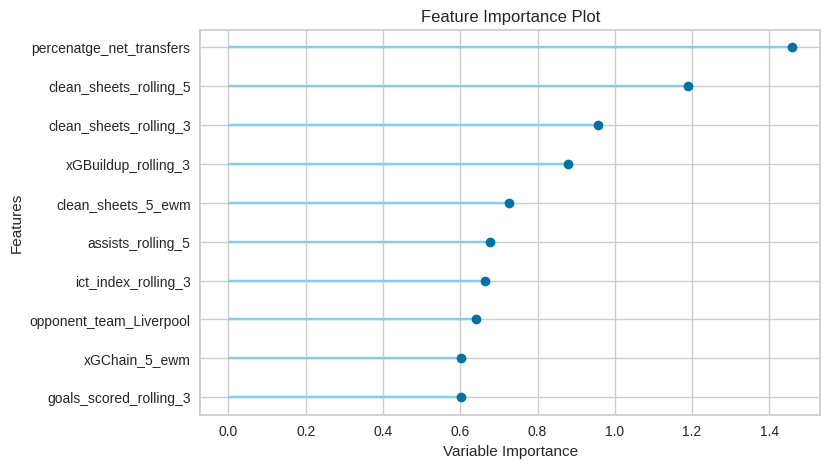

In [5]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 11)
base_model = setup(train_data, target = 'xP',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model = base_model.compare_models(sort='MAE', n_select=1)
print(best_model)

evaluate_model(best_model)

plot_model(best_model, plot='feature')        # Feature importance


## GW 12


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(1377, 342)"
4,Transformed data shape,"(1377, 128)"
5,Transformed train set shape,"(1101, 128)"
6,Transformed test set shape,"(276, 128)"
7,Numeric features,340
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7069,0.8939,0.9446,0.7514,0.2386,0.3465,1.5720
gbr,Gradient Boosting Regressor,0.7291,0.9548,0.9764,0.7335,0.2447,0.3628,1.0580
et,Extra Trees Regressor,0.7394,0.9832,0.9903,0.7267,0.2526,0.3865,1.2750
ridge,Ridge Regression,0.7415,0.9905,0.9939,0.7238,0.2498,0.3544,0.3790
xgboost,Extreme Gradient Boosting,0.7538,1.0263,1.0108,0.7161,0.2523,0.3654,0.8600
rf,Random Forest Regressor,0.7593,1.0213,1.0094,0.7163,0.2573,0.3956,2.3220
lr,Linear Regression,0.7822,1.1109,1.0530,0.6899,0.2697,0.3788,0.3500
ada,AdaBoost Regressor,0.8592,1.2111,1.0990,0.6627,0.2889,0.4980,0.6070
en,Elastic Net,0.9848,1.6069,1.2656,0.5502,0.3195,0.5142,0.3190
lasso,Lasso Regression,1.0440,1.7767,1.3310,0.5026,0.3346,0.5486,0.3120


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

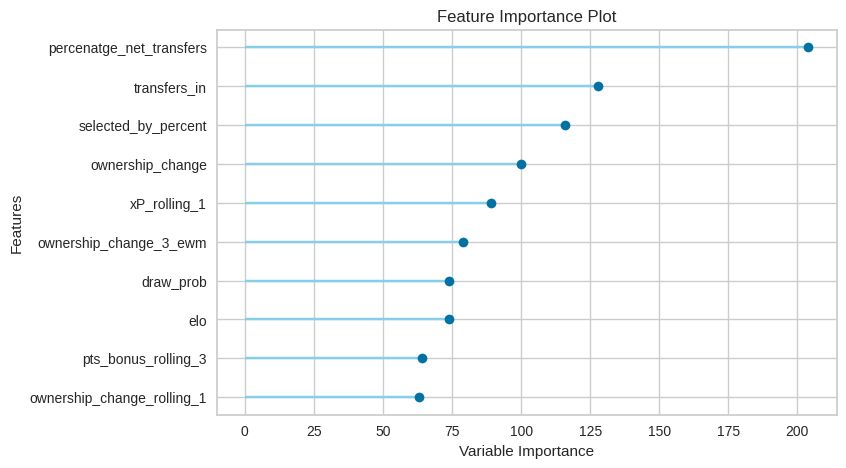

In [6]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 12)
base_model_12 = setup(train_data, target = 'xP',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_12 = base_model_12.compare_models(sort='MAE', n_select=1)
print(best_model_12)

evaluate_model(best_model_12)

plot_model(best_model_12, plot='feature')        # Feature importance


## GW 13


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(1597, 342)"
4,Transformed data shape,"(1597, 126)"
5,Transformed train set shape,"(1277, 126)"
6,Transformed test set shape,"(320, 126)"
7,Numeric features,340
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7418,1.0028,0.9993,0.7230,0.2494,0.3640,1.0870
gbr,Gradient Boosting Regressor,0.7625,1.0494,1.0211,0.7094,0.2538,0.3793,0.9640
xgboost,Extreme Gradient Boosting,0.7904,1.1418,1.0650,0.6807,0.2587,0.3754,0.8000
et,Extra Trees Regressor,0.7933,1.1327,1.0596,0.6872,0.2631,0.4025,1.2050
ridge,Ridge Regression,0.8045,1.1086,1.0515,0.6899,0.2669,0.3780,0.3290
rf,Random Forest Regressor,0.8163,1.1967,1.0902,0.6692,0.2699,0.4120,2.1750
lr,Linear Regression,0.8400,1.2489,1.1147,0.6495,0.2834,0.3920,0.3380
ada,AdaBoost Regressor,0.9850,1.4908,1.2184,0.5869,0.3207,0.5787,0.5410
en,Elastic Net,1.0267,1.7342,1.3131,0.5243,0.3293,0.5245,0.3480
lasso,Lasso Regression,1.0891,1.9117,1.3787,0.4772,0.3444,0.5601,0.3360


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

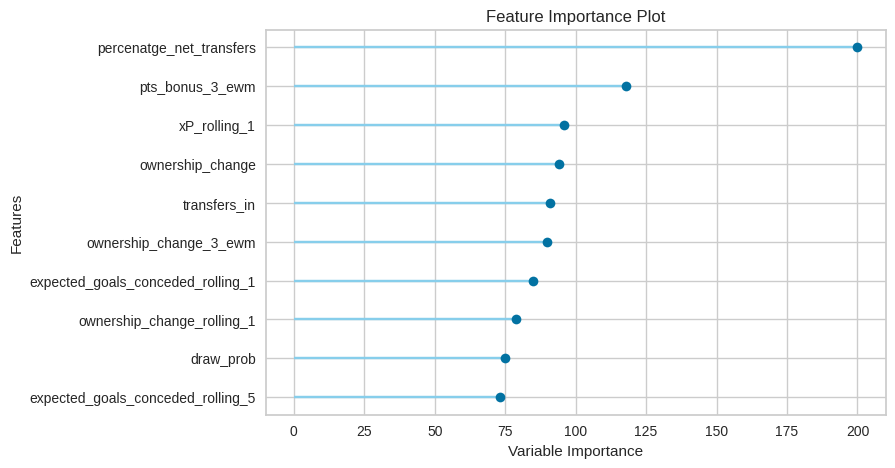

In [7]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 13)
base_model_13 = setup(train_data, target = 'xP',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_13 = base_model_13.compare_models(sort='MAE', n_select=1)
print(best_model_13)

evaluate_model(best_model_13)

plot_model(best_model_13, plot='feature')        # Feature importance


## GW 14


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(1811, 342)"
4,Transformed data shape,"(1811, 125)"
5,Transformed train set shape,"(1448, 125)"
6,Transformed test set shape,"(363, 125)"
7,Numeric features,340
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7283,0.9458,0.9686,0.7454,0.2391,0.3453,1.1210
gbr,Gradient Boosting Regressor,0.7442,0.9778,0.9841,0.7370,0.2466,0.3592,1.0900
ridge,Ridge Regression,0.7626,1.0091,1.0018,0.7255,0.2505,0.3534,0.3120
et,Extra Trees Regressor,0.7683,1.0750,1.0331,0.7098,0.2576,0.3855,1.3450
xgboost,Extreme Gradient Boosting,0.7839,1.0847,1.0378,0.7066,0.2581,0.3762,0.8500
rf,Random Forest Regressor,0.8064,1.1777,1.0816,0.6820,0.2674,0.4032,2.3960
lr,Linear Regression,0.8329,1.2059,1.0917,0.6730,0.2737,0.3846,0.3000
ada,AdaBoost Regressor,0.9044,1.3141,1.1425,0.6438,0.2971,0.5110,0.5750
en,Elastic Net,0.9858,1.6052,1.2638,0.5670,0.3179,0.5059,0.3270
lasso,Lasso Regression,1.0670,1.8303,1.3497,0.5067,0.3379,0.5505,0.3310


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

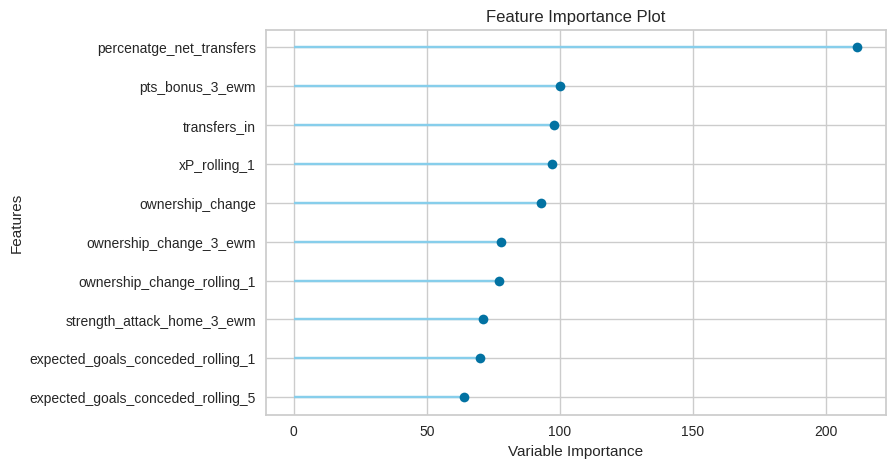

In [8]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 14)
base_model_14 = setup(train_data, target = 'xP',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_14 = base_model_14.compare_models(sort='MAE', n_select=1)
print(best_model_14)

evaluate_model(best_model_14)

plot_model(best_model_14, plot='feature')        # Feature importance


## GW 15


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(2047, 342)"
4,Transformed data shape,"(2047, 125)"
5,Transformed train set shape,"(1637, 125)"
6,Transformed test set shape,"(410, 125)"
7,Numeric features,340
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7104,0.9207,0.9580,0.7526,0.2362,0.3546,1.1480
gbr,Gradient Boosting Regressor,0.7378,0.9886,0.9924,0.7354,0.2470,0.3710,1.2060
xgboost,Extreme Gradient Boosting,0.7547,1.0235,1.0103,0.7239,0.2476,0.3659,0.8820
et,Extra Trees Regressor,0.7614,1.0528,1.0239,0.7188,0.2556,0.3982,1.5570
ridge,Ridge Regression,0.7617,1.0178,1.0077,0.7267,0.2500,0.3663,0.3270
rf,Random Forest Regressor,0.7872,1.1134,1.0526,0.7027,0.2623,0.4093,2.7350
lr,Linear Regression,0.8056,1.1365,1.0650,0.6930,0.2641,0.3863,0.3310
ada,AdaBoost Regressor,0.9304,1.3662,1.1673,0.6342,0.3091,0.5592,0.6260
en,Elastic Net,0.9856,1.6176,1.2701,0.5672,0.3176,0.5192,0.3440
lasso,Lasso Regression,1.0826,1.8980,1.3758,0.4921,0.3428,0.5733,0.3310


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

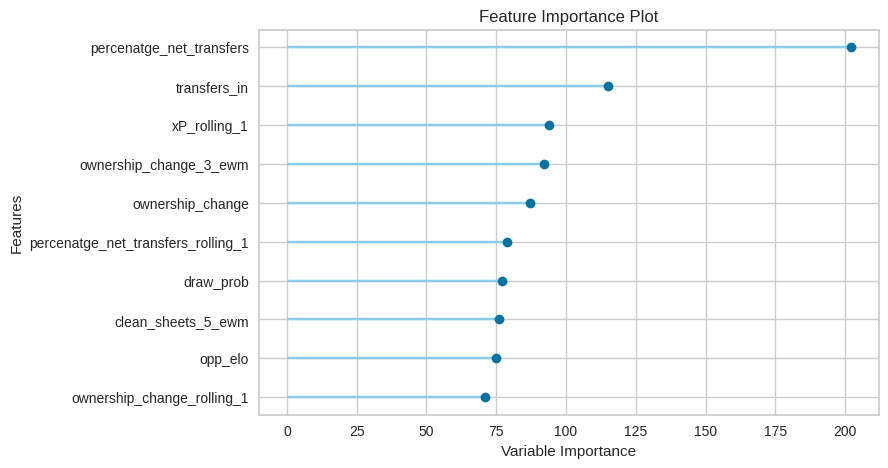

In [9]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 15)
base_model_15 = setup(train_data, target = 'xP',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_15 = base_model_15.compare_models(sort='MAE', n_select=1)
print(best_model_15)

evaluate_model(best_model_15)

plot_model(best_model_15, plot='feature')        # Feature importance


## GW 16


,Description,Value
0,Session id,42
1,Target,xP
2,Target type,Regression
3,Original data shape,"(2277, 342)"
4,Transformed data shape,"(2277, 127)"
5,Transformed train set shape,"(1821, 127)"
6,Transformed test set shape,"(456, 127)"
7,Numeric features,340
8,Preprocess,True
9,Imputation type,simple


,Model,MAE,MSE,RMSE,R2,RMSLE,MAPE,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7177,0.9553,0.9725,0.7427,0.2318,0.3223,1.7030
gbr,Gradient Boosting Regressor,0.7361,0.9924,0.9918,0.7318,0.2399,0.3400,1.9740
et,Extra Trees Regressor,0.7444,1.0115,1.0008,0.7276,0.2478,0.3606,1.9680
ridge,Ridge Regression,0.7451,0.9815,0.9846,0.7322,0.2426,0.3318,0.5090
xgboost,Extreme Gradient Boosting,0.7604,1.0869,1.0380,0.7077,0.2495,0.3453,1.4170
rf,Random Forest Regressor,0.7825,1.0958,1.0411,0.7053,0.2557,0.3756,3.6890
lr,Linear Regression,0.7897,1.0880,1.0384,0.7034,0.2590,0.3589,0.7450
ada,AdaBoost Regressor,0.9169,1.3416,1.1550,0.6351,0.3030,0.5177,1.2430
en,Elastic Net,0.9680,1.5622,1.2441,0.5764,0.3102,0.4814,0.4250
lasso,Lasso Regression,1.0592,1.8323,1.3488,0.5019,0.3350,0.5303,0.3810


LGBMRegressor(n_jobs=-1, random_state=42)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

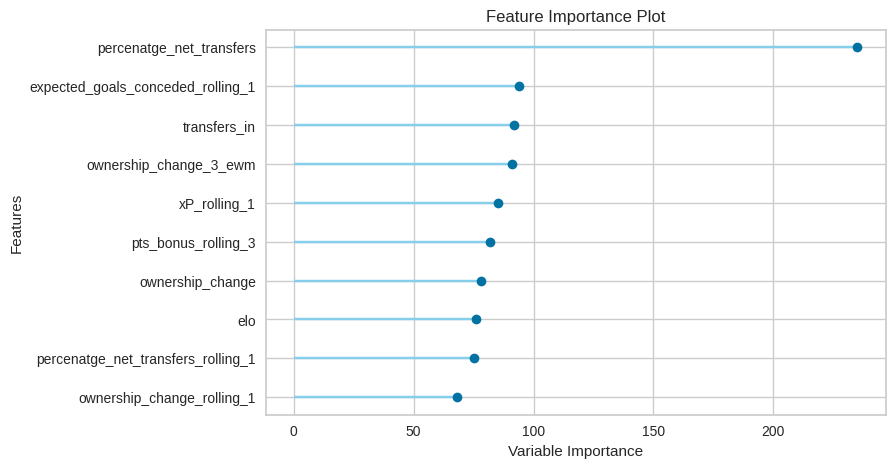

In [7]:
train_data, test_data, player_names, player_ids, test_mask = working_df(data, 16)
base_model_16 = setup(train_data, target = 'xP',
                    train_size=0.8,
                    remove_multicollinearity=True,  # Drop collinear features
                    # feature_selection=True,        # Auto-select important features
                    session_id=42,
                    # use_gpu=True


                )
# models()

best_model_16 = base_model_16.compare_models(sort='MAE', n_select=1)
print(best_model_16)

evaluate_model(best_model_16)

plot_model(best_model_16, plot='feature')        # Feature importance


## GW \_


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFE

try:
    from xgboost import XGBRegressor
    from lightgbm import LGBMRegressor
except ImportError:
    print("Ensure xgboost and lightgbm are installed to use the full tournament.")


In [11]:
class GameweekTournament:
    def __init__(self, df, candidate_features, target='target_points'):
        self.df = df
        self.features = candidate_features
        self.target = target
        self.history = []

    def evaluate_models(self, train_df, val_df):
        """
        Tests the specified model architectures on the current data slice.
        """
        X_train_raw = train_df[self.features]
        y_train = train_df[self.target]
        X_val_raw = val_df[self.features]
        y_val = val_df[self.target]

        # Scaling for linear-based models
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_raw)
        X_val_scaled = scaler.transform(X_val_raw)

        # The expanded list of models for the tournament
        models = {
            'Ridge': Ridge(alpha=1.0),
            'LinearReg': LinearRegression(),
            'RandomForest': RandomForestRegressor(n_estimators=50, random_state=42),
            'ExtraTrees': ExtraTreesRegressor(n_estimators=50, random_state=42),
            'GradientBoosting': GradientBoostingRegressor(n_estimators=50, random_state=42),
            'XGBoost': XGBRegressor(n_estimators=50, random_state=42),
            'LightGBM': LGBMRegressor(n_estimators=50, random_state=42, verbose=-1)
        }

        scores = {}
        linear_types = ['Ridge', 'LinearReg']

        for name, model in models.items():
            # Use scaled data for linear types, raw for Tree/Boosting types
            X_t = X_train_scaled if name in linear_types else X_train_raw
            X_v = X_val_scaled if name in linear_types else X_val_raw

            try:
                model.fit(X_t, y_train)
                preds = model.predict(X_v)
                scores[name] = mean_absolute_error(y_val, preds)
            except Exception as e:
                print(f"Skipping {name} due to error: {e}")

        return scores

    def get_best_features_for_model(self, model_name, train_df):
        """
        Performs feature selection specific to the winning model architecture.
        """
        X = train_df[self.features]
        y = train_df[self.target]
        linear_types = ['Ridge', 'LinearReg']

        if model_name in linear_types:
            # Use RFE with the winning linear model
            base_model = Ridge() if model_name == 'Ridge' else LinearRegression()
            selector = RFE(base_model, n_features_to_select=10)
            selector.fit(StandardScaler().fit_transform(X), y)
            return [f for f, s in zip(self.features, selector.support_) if s]

        else:
            # Tree-based selection using feature_importances_
            if model_name == 'RandomForest':
                m = RandomForestRegressor(n_estimators=50).fit(X, y)
            elif model_name == 'ExtraTrees':
                m = ExtraTreesRegressor(n_estimators=50).fit(X, y)
            elif model_name == 'GradientBoosting':
                m = GradientBoostingRegressor(n_estimators=50).fit(X, y)
            elif model_name == 'XGBoost':
                m = XGBRegressor(n_estimators=50).fit(X, y)
            elif model_name == 'LightGBM':
                m = LGBMRegressor(n_estimators=50, verbose=-1).fit(X, y)

            importances = pd.Series(m.feature_importances_, index=self.features)
            return importances.sort_values(ascending=False).head(10).index.tolist()

    def run_season_simulation(self, start_gw=5):
        """
        Main loop: Benchmarks all 7 models and selects features for every round.
        """
        max_gw = self.df['round'].max()

        for gw in range(start_gw, max_gw + 1):
            # Split data: Training (historical), Val (last week), Test (current week)
            train_data = self.df[self.df['round'] < (gw - 1)]
            val_data = self.df[self.df['round'] == (gw - 1)]
            test_data = self.df[self.df['round'] == gw]

            if val_data.empty or train_data.empty: continue

            # 1. Performance Test to find this week's "Best Model"
            scores = self.evaluate_models(train_data, val_data)
            best_model_name = min(scores, key=scores.get)

            # 2. Extract best features using the winner's logic
            best_features = self.get_best_features_for_model(best_model_name, train_data)

            # 3. Final Retrain on all available data up to the test GW
            final_train = self.df[self.df['round'] < gw]
            X_final = final_train[best_features]
            y_final = final_train[self.target]

            # Re-instantiate the winner
            if best_model_name == 'Ridge':
                m_final = Ridge()
            elif best_model_name == 'LinearReg':
                m_final = LinearRegression()
            elif best_model_name == 'RandomForest':
                m_final = RandomForestRegressor(n_estimators=50)
            elif best_model_name == 'ExtraTrees':
                m_final = ExtraTreesRegressor(n_estimators=50)
            elif best_model_name == 'GradientBoosting':
                m_final = GradientBoostingRegressor(n_estimators=50)
            elif best_model_name == 'XGBoost':
                m_final = XGBRegressor(n_estimators=50)
            elif best_model_name == 'LightGBM':
                m_final = LGBMRegressor(n_estimators=50, verbose=-1)

            # Execution
            linear_types = ['Ridge', 'LinearReg']
            if best_model_name in linear_types:
                sc = StandardScaler()
                X_f = sc.fit_transform(X_final)
                X_test = sc.transform(test_data[best_features])
                m_final.fit(X_f, y_final)
            else:
                m_final.fit(X_final, y_final)
                X_test = test_data[best_features]

            mae = mean_absolute_error(test_data[self.target], m_final.predict(X_test))

            self.history.append({
                'GW': gw,
                'BestModel': best_model_name,
                'MAE': mae,
                'TopFeature': best_features[0]
            })
            print(f"GW {gw} Winner: {best_model_name} | MAE: {mae:.4f}")

        return pd.DataFrame(self.history)

def plot_tournament_results(results_df):
    plt.figure(figsize=(14, 7))

    # Plot global error trend
    plt.plot(results_df['GW'], results_df['MAE'], marker='o', color='gray', alpha=0.3, label='MAE Trend')

    # Distinct colors for each model architecture
    palette = {
        'Ridge': '#1f77b4', 'LinearReg': '#aec7e8',
        'RandomForest': '#2ca02c', 'ExtraTrees': '#98df8a',
        'GradientBoosting': '#ff7f0e', 'XGBoost': '#d62728',
        'LightGBM': '#9467bd'
    }

    for model_name, group in results_df.groupby('BestModel'):
        plt.scatter(group['GW'], group['MAE'], color=palette.get(model_name, 'black'),
                    label=f'Winner: {model_name}', s=120, edgecolors='white', zorder=5)

    plt.title('7-Model FPL Tournament: Weekly Model Selection Results', fontsize=14)
    plt.xlabel('Gameweek', fontsize=12)
    plt.ylabel('Mean Absolute Error (Lower is Better)', fontsize=12)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, alpha=0.2)
    plt.tight_layout()
    plt.show()

## Feature Importance


In [ ]:

def select_best_features(df, features):
    """
    Ranks features using LightGBM feature importance.
    Tree models naturally calculate which features reduce variance the most.
    """
    reliable_df = df[df['round'] >= 6].copy()

    X = reliable_df[features]
    y = reliable_df['xP']

    # Use default params for ranking
    model = LGBMRegressor(n_estimators=100, random_state=42, verbose=-1)
    model.fit(X, y)

    importances = pd.DataFrame({
        'Feature': features,
        'Importance': model.feature_importances_
    }).sort_values(by='Importance', ascending=False)

    # Add a 'Rank' column to match the previous structure
    importances['Rank'] = range(1, len(importances) + 1)
    return importances

def run_reliability_test(df, selected_features):
    """
    Simulates the season using only the selected features.
    """
    gws = sorted(df['round'].unique())
    results = []
    test_start_gw = 7
    scaler = StandardScaler()

    # Range of alpha values to test
    # alphas_to_test = [0.01, 0.1, 1.0, 10.0, 100.0]
    # Hyperparameters to tune: Learning Rate and Complexity (num_leaves)
    learning_rates = [0.01, 0.05, 0.1]
    num_leaves_list = [15, 31, 63]
    best_gw_mae = float('inf')
    # best_n = 1
    # best_alpha = 1.0
    best_learning_rate = 1.0
    best_num_leaves = 10

    best_gw_mae = float('inf')
    # best_n = 1
    best_lr = 0.1
    best_leaves = 31

    # 3. Grid Search: Feature Count x Learning Rate x Leaves
    search_limit = min(len(selected_features), 12)

    # for current_gw in range(test_start_gw, max(gws) + 1):
    train_df = df[df['round'] < round]
    test_df = df[df['round'] == round]

    X_train = scaler.fit_transform(train_df[selected_features])
    X_test = scaler.transform(test_df[selected_features])

    # model = Ridge(alpha=1.0)
    # model.fit(X_train, train_df['xP'])

    for lr in learning_rates:
        for leaves in num_leaves_list:
            val_model = LGBMRegressor(
                learning_rate=lr,
                num_leaves=leaves,
                n_estimators=100,
                random_state=42,
                verbose=-1
            )
        # val_model = Ridge(alpha=a, random_state=42)
            val_model.fit(X_train, train_df['xP'])
            v_mae = mean_absolute_error(test_df['xP'], val_model.predict(X_test))

            if v_mae < best_gw_mae:
                best_gw_mae = v_mae
                # best_n = n
                best_lr = lr
                best_leaves = leaves

    results.append({'GW': round, 'MAE': best_gw_mae, 'lr': best_lr, 'leaves': best_leaves})

    return pd.DataFrame(results)


In [21]:
feature_ranks = select_best_features(data[data['round'] < 16],  feature_cols)
feature_ranks

,Feature,Importance,Rank
6,percenatge_net_transfers,183,1
38,xP_rolling_1,68,2
168,pts_bonus_3_ewm,64,3
2,transfers_in,59,4
5,ownership_change,59,5
...,...,...,...
242,ownership_change_1_ewm,0,336
239,transfers_out_1_ewm,0,337
236,transfers_in_1_ewm,0,338
233,selected_1_ewm,0,339


In [ ]:
# --- Execution ---
def get_gw_best_features(data, round):
    print(f"Step 1: Ranking Features for GW {round} using Recursive Feature Elimination...")

    feature_ranks = select_best_features(data[data['round'] < round],  feature_cols)

    # # Step 2: Automated Selection
    print(f"\nStep 2: Finding Optimal Feature Cut-off. of the {len(feature_cols)} features..")

    # We iterate through the top N features to find where MAE stops improving
    best_overall_mae = float('inf')
    best_overall_lr = 1
    best_overall_leaves = 31
    optimal_count = 1

    # Testing up to top 10 (or however many you want to check)
    search_limit = min(len(feature_cols), 50)


    for i in range(1, search_limit + 1):
        trial_features = feature_ranks.head(i)['Feature'].tolist()
        reliability_df = run_reliability_test(data[data['round']<= round], trial_features)


        avg_mae = reliability_df['MAE'].mean()
        avg_lr = reliability_df['lr'].mean()
        avg_leaves = reliability_df['leaves'].mean()


        print(f"Testing top {i} features: Average MAE = {avg_mae:.4f}")

        if avg_mae < best_overall_mae:
            best_overall_mae = avg_mae
            best_overall_lr = avg_lr
            best_overall_leaves = avg_leaves
            optimal_count = i


    # Final Prediction for the actual Deadline
    train_df = data[data['round'] < round]
    test_df = data[data['round'] == round]

    chosen_features = feature_ranks.head(optimal_count)['Feature'].tolist()

    final_model = LGBMRegressor(
        learning_rate=best_overall_lr,
        num_leaves=np.int64(best_overall_leaves),
        n_estimators=100,
        random_state=42,
        verbose=-1
    )
    print(best_overall_leaves, best_overall_lr)
    final_model.fit(train_df[chosen_features], train_df['xP'])
    actual_mae = mean_absolute_error(test_df['xP'], final_model.predict(test_df[chosen_features]))

    print(f"GW {round}: Used {len(chosen_features)} features. MAE: {actual_mae:.4f}")
    print(f"\nOptimal number of features: {optimal_count}")
    print(f"Selected Features: {round}==> {chosen_features}")

    return chosen_features, optimal_count, actual_mae, best_overall_lr, best_overall_leaves



In [30]:
selected_features = {}
for round in range(8,24):
    selected_features[round] = get_gw_best_features(data, round)


Step 1: Ranking Features for GW 8 using Recursive Feature Elimination...

Step 2: Finding Optimal Feature Cut-off. of the 340 features..
Testing top 1 features: Average MAE = 1.1678
Testing top 2 features: Average MAE = 1.0909
Testing top 3 features: Average MAE = 0.9714
Testing top 4 features: Average MAE = 0.9551
Testing top 5 features: Average MAE = 0.9210
Testing top 6 features: Average MAE = 0.8913
Testing top 7 features: Average MAE = 0.9262
Testing top 8 features: Average MAE = 0.9321
Testing top 9 features: Average MAE = 0.9108
Testing top 10 features: Average MAE = 0.8835
Testing top 11 features: Average MAE = 0.8820
Testing top 12 features: Average MAE = 0.8794
Testing top 13 features: Average MAE = 0.9033
Testing top 14 features: Average MAE = 0.8876
Testing top 15 features: Average MAE = 0.8789
Testing top 16 features: Average MAE = 0.8593
Testing top 17 features: Average MAE = 0.8689
Testing top 18 features: Average MAE = 0.8850
Testing top 19 features: Average MAE = 0.883

In [34]:
selections = pd.DataFrame(selected_features).T
selections.columns = ['best_features', 'optimal_count', 'best_overall_mae', 'best_lr', 'best_leaves']
selections

,best_features,optimal_count,best_overall_mae,best_lr,best_leaves
8,"[percenatge_net_transfers, transfers_in, pts_b...",32,0.844301,0.1,31.0
9,"[percenatge_net_transfers, transfers_in, owner...",47,0.739452,0.1,15.0
10,"[percenatge_net_transfers, transfers_in, owner...",49,0.751067,0.1,15.0
11,"[percenatge_net_transfers, transfers_in, owner...",33,0.851061,0.05,31.0
12,"[percenatge_net_transfers, transfers_in, owner...",12,0.979615,0.1,63.0
13,"[percenatge_net_transfers, ownership_change, p...",34,0.798859,0.1,15.0
14,"[percenatge_net_transfers, transfers_in, xP_ro...",43,0.667274,0.05,15.0
15,"[percenatge_net_transfers, transfers_in, owner...",33,0.665388,0.05,15.0
16,"[percenatge_net_transfers, xP_rolling_1, pts_b...",47,0.700192,0.05,15.0
17,"[percenatge_net_transfers, xP_rolling_1, pts_b...",10,0.658128,0.05,15.0


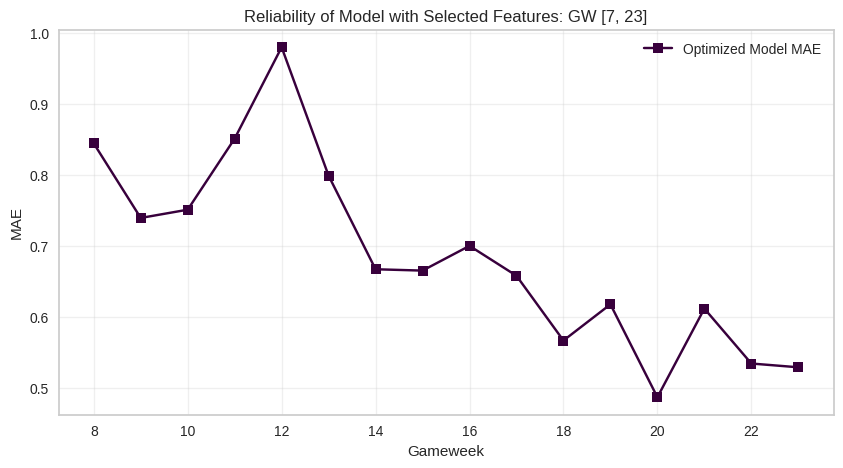

In [35]:

# --- Visualization ---
plt.figure(figsize=(10, 5))
plt.plot(selections.index, selections['best_overall_mae'], marker='s', color="#38003c", label='Optimized Model MAE')
plt.title('Reliability of Model with Selected Features: GW [7, 23]', fontsize=12)
plt.xlabel('Gameweek')
plt.ylabel('MAE')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [ ]:
110+21+25+35+15+15+40+24+1.4+7+45+1.8+20

360.2

# 24-25


## Functions


In [70]:
def working_df(data, gw, features=None):
    data_24 = data[data['season'] == 2024]
    data_25 = data[data['season'] == 2025]

    GW_full = data_25['round'].values

    # Split
    GW_TRAIN_END = gw - 1
    train_mask = GW_full <= GW_TRAIN_END
    test_mask = GW_full == (GW_TRAIN_END + 1)

    train_data = data_25[train_mask]
    test_data = data_25[test_mask]

    train_data = pd.concat([data_24, train_data])

    test_player_names = test_data['fpl_name'].values
    test_player_ids = test_data['fpl_id'].values
    # test_player_positions = test_data['position'].values
    test_data = test_data.drop(columns=['fpl_name', 'fpl_id', 'team_id', 'round'])
    train_data = train_data.drop(columns=['fpl_name', 'fpl_id', 'team_id', 'round'])

    return train_data, test_data, test_player_names, test_player_ids, test_mask

def plot_preds(preds, position, gw, full_data, test_mask):
    # xp_actual = test_target
    # xp_pred = preds #['prediction_label'].values
    # position = data_25_26[test_mask]['position'].values

    preds_data = pd.DataFrame({
        'fpl_name': full_data[test_mask]['fpl_name'].values,
        'Actual_xP':  full_data[test_mask]['xP'].values,
        'Pred_xP': preds,
        'position': full_data[test_mask]['position'].values
    })

    position = position
    names = preds_data[preds_data['position'] == position]['fpl_name'].values
    xp_actual = preds_data[preds_data['position'] == position]['Actual_xP'].values
    xp_pred = preds_data[preds_data['position'] == position]['Pred_xP'].values


    # Convert names to positions on x-axis
    x = np.arange(len(names))

    plt.figure(figsize=(14, 6))

    # Plot actual points
    plt.plot(x, xp_actual, marker='o', linewidth=2, label='Actual Points')

    # Plot predicted points
    plt.plot(x, xp_pred, marker='x', linewidth=2, label='Predicted Points')

    # Improve readability
    plt.xticks(x, names, rotation=75, ha='right')
    plt.xlabel("Players")
    plt.ylabel("Points")
    plt.title(f" : Actual vs Predicted Points per Player for position {position} (GW {gw})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # Width of each bar
    width = 0.31

    plt.figure(figsize=(14, 6))

    # Bars
    plt.bar(x - width/2, xp_actual, width, label='Actual Points')
    plt.bar(x + width/2, xp_pred, width, label='Predicted Points')

    # Labels & formatting
    plt.xticks(x, names, rotation=75, ha='right')
    plt.xlabel("Players")
    plt.ylabel("Points")
    plt.title(f" {position} : Actual vs Predicted Points per Player for position {position} (GW {gw})")
    plt.legend()

    plt.tight_layout()
    plt.show()


## Data Prep


In [62]:
# all_data = pd.read_csv('https://raw.githubusercontent.com/ilyandho/FPL-Optimal-Transfer/refs/heads/FantasyGo/Prediction%20with%20Affine%20PNN/data/rolled_player_data.csv')
all_data = pd.read_csv('../Prediction with Affine PNN/data/all_data.csv')
all_data

,season,understat_id,round,h_goals,team_h_difficulty,chance_of_playing_next_round,goals_conceded,clearances_blocks_interceptions,selected_by_percent,season_clearances_blocks_interceptions,...,strength_defence_home_5_ewm,strength_defence_away_1_ewm,strength_defence_away_3_ewm,strength_defence_away_5_ewm,opponent_team_name,opp_clean_sheets,opp_elo_h,opp_elo_a,opp_elo,opp_strength
0,2024,65.0,1,0.0,2.0,0.0,0.0,0.0,0.3,0.0,...,0.000000,0.0,0.000000,0.000000,Leicester_2024,0.0,1741.20,1830.21,1741.20,0.0
1,2024,65.0,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.000000,0,0.0,0.00,0.00,0.00,0.0
2,2024,65.0,3,0.0,2.0,0.0,1.0,2.0,0.2,0.0,...,0.000000,0.0,0.000000,0.000000,Newcastle_2024,0.0,1741.20,1830.21,1741.20,0.0
3,2024,65.0,4,0.0,5.0,0.0,0.0,0.0,0.2,2.0,...,0.000000,0.0,0.000000,0.000000,Arsenal_2024,1.0,1702.37,1981.59,1981.59,0.0
4,2024,65.0,5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.000000,0.000000,0,0.0,0.00,0.00,0.00,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62315,2025,14328.0,34,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,10.231503,0.0,1.230469,10.925164,0,0.0,0.00,0.00,0.00,0.0
62316,2025,14328.0,35,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.821002,0.0,0.615234,7.283443,0,0.0,0.00,0.00,0.00,0.0
62317,2025,14328.0,36,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,4.547335,0.0,0.307617,4.855628,0,0.0,0.00,0.00,0.00,0.0
62318,2025,14328.0,37,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,3.031556,0.0,0.153809,3.237086,0,0.0,0.00,0.00,0.00,0.0


In [ ]:

# gw=24

cols = [

    'fpl_id', 'round', 'fpl_name', 'position', 'team_id', 'team', 'season', 'opponent_team', 'was_home', 'xP',# 'xP_next',
    'selected_by_percent','value', 'transfers_in', 'transfers_out',  'selected', 'ownership_change', 'percenatge_net_transfers',
    'cbitr_volume_90', 'cbitr_ewm_90', 'cbitr_ewm_probability',  'cbitr_probability','elo',  'team_h_difficulty', 'team_a_difficulty',
    'win_prob', 'draw_prob', 'lose_prob',


    'creativity_rolling_1', 'creativity_rolling_3', 'creativity_rolling_5', 'influence_rolling_1', 'influence_rolling_3', 'influence_rolling_5', 'threat_rolling_1',
    'threat_rolling_3', 'threat_rolling_5', 'minutes_rolling_1', 'minutes_rolling_3', 'minutes_rolling_5', 'pts_bonus_rolling_1', 'pts_bonus_rolling_3',
    'pts_bonus_rolling_5', 'expected_goals_rolling_1', 'expected_goals_rolling_3', 'expected_goals_rolling_5', 'expected_assists_rolling_1',
    'expected_assists_rolling_3', 'expected_assists_rolling_5', 'xP_rolling_1', 'xP_rolling_3', 'xP_rolling_5', 'expected_goals_conceded_rolling_1',
    'expected_goals_conceded_rolling_3', 'expected_goals_conceded_rolling_5', 'goals_conceded_rolling_1', 'goals_conceded_rolling_3', 'goals_conceded_rolling_5',
    'goals_scored_rolling_1', 'goals_scored_rolling_3', 'goals_scored_rolling_5', 'shots_rolling_1', 'shots_rolling_3', 'shots_rolling_5', 'key_passes_rolling_1',
    'key_passes_rolling_3', 'key_passes_rolling_5', 'npg_rolling_1', 'npg_rolling_3', 'npg_rolling_5', 'npxG_rolling_1', 'npxG_rolling_3', 'npxG_rolling_5',
    'goals_rolling_1', 'goals_rolling_3', 'goals_rolling_5', 'xG_rolling_1', 'xG_rolling_3', 'xG_rolling_5', 'xA_rolling_1', 'xA_rolling_3', 'xA_rolling_5',
    'saves_rolling_1', 'saves_rolling_3', 'saves_rolling_5', 'starts_rolling_1', 'starts_rolling_3', 'starts_rolling_5', 'yellow_cards_rolling_1',
    'yellow_cards_rolling_3', 'yellow_cards_rolling_5', 'red_cards_rolling_1', 'red_cards_rolling_3', 'red_cards_rolling_5', 'assists_rolling_1', 'assists_rolling_3',
    'assists_rolling_5', 'clean_sheets_rolling_1', 'clean_sheets_rolling_3', 'clean_sheets_rolling_5', 'value_rolling_1', 'value_rolling_3', 'value_rolling_5',
    'ict_index_rolling_1', 'ict_index_rolling_3', 'ict_index_rolling_5', 'selected_rolling_1', 'selected_rolling_3', 'selected_rolling_5', 'transfers_in_rolling_1',
    'transfers_in_rolling_3', 'transfers_in_rolling_5', 'transfers_out_rolling_1', 'transfers_out_rolling_3', 'transfers_out_rolling_5', 'ownership_change_rolling_1',
    'ownership_change_rolling_3', 'ownership_change_rolling_5', 'percenatge_net_transfers_rolling_1', 'percenatge_net_transfers_rolling_3',
    'percenatge_net_transfers_rolling_5', 'xGChain_rolling_1', 'xGChain_rolling_3', 'xGChain_rolling_5', 'xGBuildup_rolling_1', 'xGBuildup_rolling_3',
    'xGBuildup_rolling_5', 'expected_goal_involvements_rolling_1', 'expected_goal_involvements_rolling_3', 'expected_goal_involvements_rolling_5', 'form_rolling_1',
    'form_rolling_3', 'form_rolling_5', 'clearances_blocks_interceptions_rolling_1', 'clearances_blocks_interceptions_rolling_3',
    'clearances_blocks_interceptions_rolling_5', 'tackles_rolling_1', 'tackles_rolling_3', 'tackles_rolling_5', 'recoveries_rolling_1', 'recoveries_rolling_3',
    'recoveries_rolling_5', 'selected_by_percent_rolling_1', 'selected_by_percent_rolling_3', 'selected_by_percent_rolling_5', 'strength_rolling_1',
    'strength_rolling_3', 'strength_rolling_5', 'strength_overall_home_rolling_1', 'strength_overall_home_rolling_3', 'strength_overall_home_rolling_5',
    'strength_overall_away_rolling_1', 'strength_overall_away_rolling_3', 'strength_overall_away_rolling_5', 'strength_attack_home_rolling_1',
    'strength_attack_home_rolling_3', 'strength_attack_home_rolling_5', 'strength_attack_away_rolling_1', 'strength_attack_away_rolling_3',
    'strength_attack_away_rolling_5', 'strength_defence_home_rolling_1', 'strength_defence_home_rolling_3', 'strength_defence_home_rolling_5',
    'strength_defence_away_rolling_1', 'strength_defence_away_rolling_3', 'strength_defence_away_rolling_5',

    'creativity_1_ewm', 'creativity_3_ewm', 'creativity_5_ewm', 'influence_1_ewm', 'influence_3_ewm', 'influence_5_ewm', 'threat_1_ewm', 'threat_3_ewm', 'threat_5_ewm',
    'minutes_1_ewm', 'minutes_3_ewm', 'minutes_5_ewm', 'pts_bonus_1_ewm', 'pts_bonus_3_ewm', 'pts_bonus_5_ewm', 'expected_goals_1_ewm', 'expected_goals_3_ewm',
    'expected_goals_5_ewm', 'expected_assists_1_ewm', 'expected_assists_3_ewm', 'expected_assists_5_ewm', 'xP_1_ewm', 'xP_3_ewm', 'xP_5_ewm',
    'expected_goals_conceded_1_ewm', 'expected_goals_conceded_3_ewm', 'expected_goals_conceded_5_ewm', 'goals_conceded_1_ewm', 'goals_conceded_3_ewm',
    'goals_conceded_5_ewm', 'goals_scored_1_ewm', 'goals_scored_3_ewm', 'goals_scored_5_ewm', 'shots_1_ewm', 'shots_3_ewm', 'shots_5_ewm', 'key_passes_1_ewm',
    'key_passes_3_ewm', 'key_passes_5_ewm', 'npg_1_ewm', 'npg_3_ewm', 'npg_5_ewm', 'npxG_1_ewm', 'npxG_3_ewm', 'npxG_5_ewm', 'goals_1_ewm', 'goals_3_ewm',
    'goals_5_ewm', 'xG_1_ewm', 'xG_3_ewm', 'xG_5_ewm', 'xA_1_ewm', 'xA_3_ewm', 'xA_5_ewm', 'saves_1_ewm', 'saves_3_ewm', 'saves_5_ewm', 'starts_1_ewm', 'starts_3_ewm',
    'starts_5_ewm', 'yellow_cards_1_ewm', 'yellow_cards_3_ewm', 'yellow_cards_5_ewm', 'red_cards_1_ewm', 'red_cards_3_ewm', 'red_cards_5_ewm', 'assists_1_ewm',
    'assists_3_ewm', 'assists_5_ewm', 'clean_sheets_1_ewm', 'clean_sheets_3_ewm', 'clean_sheets_5_ewm', 'value_1_ewm', 'value_3_ewm', 'value_5_ewm', 'ict_index_1_ewm',
    'ict_index_3_ewm', 'ict_index_5_ewm', 'selected_1_ewm', 'selected_3_ewm', 'selected_5_ewm', 'transfers_in_1_ewm', 'transfers_in_3_ewm', 'transfers_in_5_ewm',
    'transfers_out_1_ewm', 'transfers_out_3_ewm', 'transfers_out_5_ewm', 'ownership_change_1_ewm', 'ownership_change_3_ewm', 'ownership_change_5_ewm',
    'percenatge_net_transfers_1_ewm', 'percenatge_net_transfers_3_ewm', 'percenatge_net_transfers_5_ewm', 'xGChain_1_ewm', 'xGChain_3_ewm', 'xGChain_5_ewm',
    'xGBuildup_1_ewm', 'xGBuildup_3_ewm', 'xGBuildup_5_ewm', 'expected_goal_involvements_1_ewm', 'expected_goal_involvements_3_ewm', 'expected_goal_involvements_5_ewm',
    'form_1_ewm', 'form_3_ewm', 'form_5_ewm', 'clearances_blocks_interceptions_1_ewm', 'clearances_blocks_interceptions_3_ewm', 'clearances_blocks_interceptions_5_ewm',
    'tackles_1_ewm', 'tackles_3_ewm', 'tackles_5_ewm', 'recoveries_1_ewm', 'recoveries_3_ewm', 'recoveries_5_ewm', 'selected_by_percent_1_ewm',
    'selected_by_percent_3_ewm', 'selected_by_percent_5_ewm', 'strength_1_ewm', 'strength_3_ewm', 'strength_5_ewm', 'strength_overall_home_1_ewm',
    'strength_overall_home_3_ewm', 'strength_overall_home_5_ewm', 'strength_overall_away_1_ewm', 'strength_overall_away_3_ewm', 'strength_overall_away_5_ewm',
    'strength_attack_home_1_ewm', 'strength_attack_home_3_ewm', 'strength_attack_home_5_ewm', 'strength_attack_away_1_ewm', 'strength_attack_away_3_ewm',
    'strength_attack_away_5_ewm', 'strength_defence_home_1_ewm', 'strength_defence_home_3_ewm', 'strength_defence_home_5_ewm', 'strength_defence_away_1_ewm',
    'strength_defence_away_3_ewm', 'strength_defence_away_5_ewm',

    'opp_elo', 'opp_clean_sheets', 'opp_strength'
    ]

all_data = all_data.rename({'web_name': 'fpl_name'}, axis=1)

all_data_24 = all_data[all_data['season'] == 2024]
all_data_25 = all_data[all_data['season'] == 2025]
all_data_24

hist_data_24 = all_data_24[
    # (all_data_24['round'] > 5)  &
    (all_data_24['minutes_rolling_3'] > 15) &
    (all_data_24['minutes'] > 15)
    ]

hist_data_25 = all_data_25[
    # (all_data_25['round'] > 5)  &
    (all_data_25['minutes_rolling_3'] > 15) &
    (all_data_25['minutes'] > 15)
    ]
# Cater for round = 1: rolling_3 = 0
hist_data_25_1 = all_data_25[
    (all_data_25['round'] == 1)  &
    # (all_data_25['minutes_rolling_3'] > 15) &
    (all_data_25['minutes'] > 15)
    ]

hist_data_25 = pd.concat([hist_data_25_1, hist_data_25])

# Make sure round = gw is include: it doesn't meet most of the filters
tar_data = all_data_25[
                        (all_data_25['round'] == gw) &
                        (all_data_25['minutes_rolling_3'] >= 15)
                    ]

all_data_ = pd.concat([hist_data_24, hist_data_25, tar_data])

active_data = all_data_[cols].copy()
active_data_ = active_data.copy()


CATEGORICAL_COLS = ['position', 'team', 'opponent_team']

# Initialize encoder
# handle_unknown='ignore' ensures new teams result in all-zero rows for those features
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

# Fit and transform the categorical columns
encoded_array = encoder.fit(active_data_[CATEGORICAL_COLS])

# Create a DataFrame with the encoded features
encoded_cols = encoder.get_feature_names_out(CATEGORICAL_COLS)
encoded_df = pd.DataFrame(
    encoder.transform(active_data_[CATEGORICAL_COLS]),
    columns=encoded_cols,
    index=active_data_.index
)

cols = [*cols, *encoded_cols]
# Combine with numerical data
data = pd.concat([active_data_, encoded_df], axis=1).drop(columns=CATEGORICAL_COLS)

feature_cols = [
    'selected_by_percent', 'value', 'transfers_in', 'transfers_out', 'selected', 'ownership_change', 'percenatge_net_transfers', 'cbitr_volume_90', 'cbitr_ewm_90',
    'cbitr_ewm_probability', 'cbitr_probability', 'elo', 'team_h_difficulty', 'team_a_difficulty', 'win_prob', 'draw_prob', 'lose_prob', 'creativity_rolling_1',
    'creativity_rolling_3', 'creativity_rolling_5', 'influence_rolling_1', 'influence_rolling_3', 'influence_rolling_5', 'threat_rolling_1', 'threat_rolling_3',
    'threat_rolling_5', 'minutes_rolling_1', 'minutes_rolling_3', 'minutes_rolling_5', 'pts_bonus_rolling_1', 'pts_bonus_rolling_3', 'pts_bonus_rolling_5',
    'expected_goals_rolling_1', 'expected_goals_rolling_3', 'expected_goals_rolling_5', 'expected_assists_rolling_1', 'expected_assists_rolling_3',
    'expected_assists_rolling_5', 'xP_rolling_1', 'xP_rolling_3', 'xP_rolling_5', 'expected_goals_conceded_rolling_1', 'expected_goals_conceded_rolling_3',
    'expected_goals_conceded_rolling_5', 'goals_conceded_rolling_1', 'goals_conceded_rolling_3', 'goals_conceded_rolling_5', 'goals_scored_rolling_1',
    'goals_scored_rolling_3', 'goals_scored_rolling_5', 'shots_rolling_1', 'shots_rolling_3', 'shots_rolling_5', 'key_passes_rolling_1', 'key_passes_rolling_3',
    'key_passes_rolling_5', 'npg_rolling_1', 'npg_rolling_3', 'npg_rolling_5', 'npxG_rolling_1', 'npxG_rolling_3', 'npxG_rolling_5', 'goals_rolling_1',
    'goals_rolling_3', 'goals_rolling_5', 'xG_rolling_1', 'xG_rolling_3', 'xG_rolling_5', 'xA_rolling_1', 'xA_rolling_3', 'xA_rolling_5', 'saves_rolling_1',
    'saves_rolling_3', 'saves_rolling_5', 'starts_rolling_1', 'starts_rolling_3', 'starts_rolling_5', 'yellow_cards_rolling_1', 'yellow_cards_rolling_3',
    'yellow_cards_rolling_5', 'red_cards_rolling_1', 'red_cards_rolling_3', 'red_cards_rolling_5', 'assists_rolling_1', 'assists_rolling_3', 'assists_rolling_5',
    'clean_sheets_rolling_1', 'clean_sheets_rolling_3', 'clean_sheets_rolling_5', 'value_rolling_1', 'value_rolling_3', 'value_rolling_5', 'ict_index_rolling_1',
    'ict_index_rolling_3', 'ict_index_rolling_5', 'selected_rolling_1', 'selected_rolling_3', 'selected_rolling_5', 'transfers_in_rolling_1', 'transfers_in_rolling_3',
    'transfers_in_rolling_5', 'transfers_out_rolling_1', 'transfers_out_rolling_3', 'transfers_out_rolling_5', 'ownership_change_rolling_1',
    'ownership_change_rolling_3', 'ownership_change_rolling_5', 'percenatge_net_transfers_rolling_1', 'percenatge_net_transfers_rolling_3',
    'percenatge_net_transfers_rolling_5', 'xGChain_rolling_1', 'xGChain_rolling_3', 'xGChain_rolling_5', 'xGBuildup_rolling_1', 'xGBuildup_rolling_3',
    'xGBuildup_rolling_5', 'expected_goal_involvements_rolling_1', 'expected_goal_involvements_rolling_3', 'expected_goal_involvements_rolling_5', 'form_rolling_1',
    'form_rolling_3', 'form_rolling_5', 'clearances_blocks_interceptions_rolling_1', 'clearances_blocks_interceptions_rolling_3',
    'clearances_blocks_interceptions_rolling_5', 'tackles_rolling_1', 'tackles_rolling_3', 'tackles_rolling_5', 'recoveries_rolling_1', 'recoveries_rolling_3',
    'recoveries_rolling_5', 'selected_by_percent_rolling_1', 'selected_by_percent_rolling_3', 'selected_by_percent_rolling_5', 'strength_rolling_1',
    'strength_rolling_3', 'strength_rolling_5', 'strength_overall_home_rolling_1', 'strength_overall_home_rolling_3', 'strength_overall_home_rolling_5',
    'strength_overall_away_rolling_1', 'strength_overall_away_rolling_3', 'strength_overall_away_rolling_5', 'strength_attack_home_rolling_1',
    'strength_attack_home_rolling_3', 'strength_attack_home_rolling_5', 'strength_attack_away_rolling_1', 'strength_attack_away_rolling_3',
    'strength_attack_away_rolling_5', 'strength_defence_home_rolling_1', 'strength_defence_home_rolling_3', 'strength_defence_home_rolling_5',
    'strength_defence_away_rolling_1', 'strength_defence_away_rolling_3', 'strength_defence_away_rolling_5', 'creativity_1_ewm', 'creativity_3_ewm', 'creativity_5_ewm',
    'influence_1_ewm', 'influence_3_ewm', 'influence_5_ewm', 'threat_1_ewm', 'threat_3_ewm', 'threat_5_ewm', 'minutes_1_ewm', 'minutes_3_ewm', 'minutes_5_ewm',
    'pts_bonus_1_ewm', 'pts_bonus_3_ewm', 'pts_bonus_5_ewm', 'expected_goals_1_ewm', 'expected_goals_3_ewm', 'expected_goals_5_ewm', 'expected_assists_1_ewm',
    'expected_assists_3_ewm', 'expected_assists_5_ewm', 'xP_1_ewm', 'xP_3_ewm', 'xP_5_ewm', 'expected_goals_conceded_1_ewm', 'expected_goals_conceded_3_ewm',
    'expected_goals_conceded_5_ewm', 'goals_conceded_1_ewm', 'goals_conceded_3_ewm', 'goals_conceded_5_ewm', 'goals_scored_1_ewm', 'goals_scored_3_ewm',
    'goals_scored_5_ewm', 'shots_1_ewm', 'shots_3_ewm', 'shots_5_ewm', 'key_passes_1_ewm', 'key_passes_3_ewm', 'key_passes_5_ewm', 'npg_1_ewm', 'npg_3_ewm', 'npg_5_ewm',
    'npxG_1_ewm', 'npxG_3_ewm', 'npxG_5_ewm', 'goals_1_ewm', 'goals_3_ewm', 'goals_5_ewm', 'xG_1_ewm', 'xG_3_ewm', 'xG_5_ewm', 'xA_1_ewm', 'xA_3_ewm', 'xA_5_ewm',
    'saves_1_ewm', 'saves_3_ewm', 'saves_5_ewm', 'starts_1_ewm', 'starts_3_ewm', 'starts_5_ewm', 'yellow_cards_1_ewm', 'yellow_cards_3_ewm', 'yellow_cards_5_ewm',
    'red_cards_1_ewm', 'red_cards_3_ewm', 'red_cards_5_ewm', 'assists_1_ewm', 'assists_3_ewm', 'assists_5_ewm', 'clean_sheets_1_ewm', 'clean_sheets_3_ewm',
    'clean_sheets_5_ewm', 'value_1_ewm', 'value_3_ewm', 'value_5_ewm', 'ict_index_1_ewm', 'ict_index_3_ewm', 'ict_index_5_ewm', 'selected_1_ewm', 'selected_3_ewm',
    'selected_5_ewm', 'transfers_in_1_ewm', 'transfers_in_3_ewm', 'transfers_in_5_ewm', 'transfers_out_1_ewm', 'transfers_out_3_ewm', 'transfers_out_5_ewm',
    'ownership_change_1_ewm', 'ownership_change_3_ewm', 'ownership_change_5_ewm', 'percenatge_net_transfers_1_ewm', 'percenatge_net_transfers_3_ewm',
    'percenatge_net_transfers_5_ewm', 'xGChain_1_ewm', 'xGChain_3_ewm', 'xGChain_5_ewm', 'xGBuildup_1_ewm', 'xGBuildup_3_ewm', 'xGBuildup_5_ewm',
    'expected_goal_involvements_1_ewm', 'expected_goal_involvements_3_ewm', 'expected_goal_involvements_5_ewm', 'form_1_ewm', 'form_3_ewm', 'form_5_ewm',
    'clearances_blocks_interceptions_1_ewm', 'clearances_blocks_interceptions_3_ewm', 'clearances_blocks_interceptions_5_ewm', 'tackles_1_ewm', 'tackles_3_ewm',
    'tackles_5_ewm', 'recoveries_1_ewm', 'recoveries_3_ewm', 'recoveries_5_ewm', 'selected_by_percent_1_ewm', 'selected_by_percent_3_ewm', 'selected_by_percent_5_ewm',
    'strength_1_ewm', 'strength_3_ewm', 'strength_5_ewm', 'strength_overall_home_1_ewm', 'strength_overall_home_3_ewm', 'strength_overall_home_5_ewm',
    'strength_overall_away_1_ewm', 'strength_overall_away_3_ewm', 'strength_overall_away_5_ewm', 'strength_attack_home_1_ewm', 'strength_attack_home_3_ewm',
    'strength_attack_home_5_ewm', 'strength_attack_away_1_ewm', 'strength_attack_away_3_ewm', 'strength_attack_away_5_ewm', 'strength_defence_home_1_ewm',
    'strength_defence_home_3_ewm', 'strength_defence_home_5_ewm', 'strength_defence_away_1_ewm', 'strength_defence_away_3_ewm', 'strength_defence_away_5_ewm', 'opp_elo',
    'opp_clean_sheets', 'opp_strength', 'position_DEF', 'position_FWD', 'position_GK', 'position_MID', 'team_Arsenal', 'team_Aston Villa', 'team_Bournemouth',
    'team_Brentford', 'team_Brighton', 'team_Burnley', 'team_Chelsea', 'team_Crystal Palace', 'team_Everton', 'team_Fulham', 'team_Leeds', 'team_Liverpool',
    'team_Man City', 'team_Man Utd', 'team_Newcastle', "team_Nott'm Forest", 'team_Spurs', 'team_Sunderland', 'team_West Ham', 'team_Wolves', 'opponent_team_Arsenal',
    'opponent_team_Aston Villa', 'opponent_team_Bournemouth', 'opponent_team_Brentford', 'opponent_team_Brighton', 'opponent_team_Burnley', 'opponent_team_Chelsea',
    'opponent_team_Crystal Palace', 'opponent_team_Everton', 'opponent_team_Fulham', 'opponent_team_Leeds', 'opponent_team_Liverpool', 'opponent_team_Man City',
    'opponent_team_Man Utd', 'opponent_team_Newcastle', "opponent_team_Nott'm Forest", 'opponent_team_Spurs', 'opponent_team_Sunderland', 'opponent_team_West Ham',
    'opponent_team_Wolves'
]

data

,fpl_id,round,fpl_name,fpl_name,team_id,season,was_home,xP,selected_by_percent,value,...,opponent_team_Nott'm Forest_2024,opponent_team_Nott'm Forest_2025,opponent_team_Southampton_2024,opponent_team_Spurs_2024,opponent_team_Spurs_2025,opponent_team_Sunderland_2025,opponent_team_West Ham_2024,opponent_team_West Ham_2025,opponent_team_Wolves_2024,opponent_team_Wolves_2025
6,509.0,7,Werner,Werner,0.0,2024,False,2.2,0.2,62.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,509.0,8,Werner,Werner,0.0,2024,True,3.5,0.2,62.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
8,509.0,9,Werner,Werner,0.0,2024,False,3.0,0.2,62.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
10,509.0,11,Werner,Werner,0.0,2024,True,0.3,0.2,62.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
14,509.0,15,Werner,Werner,0.0,2024,True,3.2,0.2,62.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58049,672.0,24,Hato,Hato,7.0,2025,True,0.0,0.2,46.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
58201,526.0,24,Igor Jesus,Igor Jesus,16.0,2025,True,0.0,1.0,58.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59037,731.0,24,Kevin,Kevin,10.0,2025,False,0.0,0.1,58.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
59265,733.0,24,Lammens,Lammens,14.0,2025,True,0.0,1.8,50.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Feature Importance
